# STEP 1 : Formulate Research Question

**Research Question** :

- “Can we predict whether a tumor is malignant or benign using cell nucleus features with the K‑Nearest Neighbors algorithm?”

**Identification of Variables**

**Dependent Variable (y):**

- diagnosis (Malignant = 1, Benign = 0)

**Independent Variables (X):**
- radius_mean
- texture_mean
- perimeter_mean

**Objective**  
- The objective is to build a KNN classification model that predicts tumor diagnosis based on cell features, evaluate multiple K values, and interpret the best model’s performance.

# STEP 2 : Data Validation and Cleaning

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("breast-cancer.csv")

# Inspect dataset
df.head()
df.shape
df.info()
df.describe()

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Remove irrelevant column
df = df.drop(columns=['id'])

# Encode target variable
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Drop missing values if any
df = df.dropna()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

**Summary Findings:**  
- The dataset was inspected for structure, missing values, and duplicates. The id column was removed. The target variable was encoded (M=1, B=0). Data quality was ensured for modeling.

# STEP 3 : Exploratory Data Analysis (EDA)

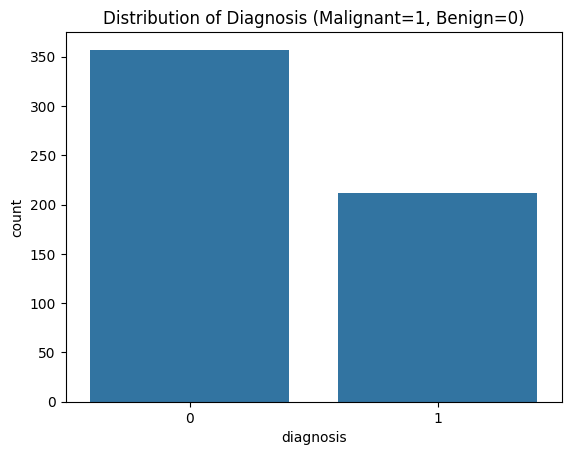

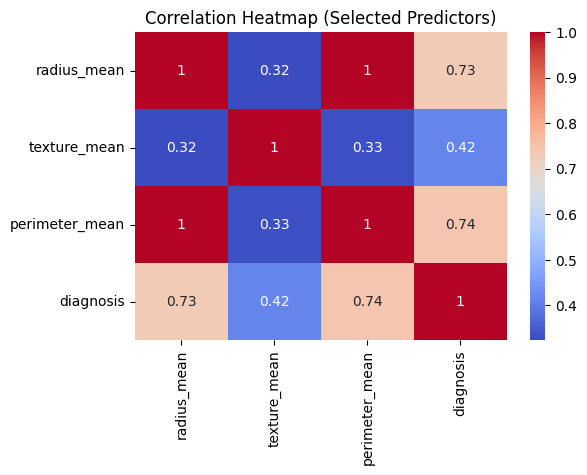

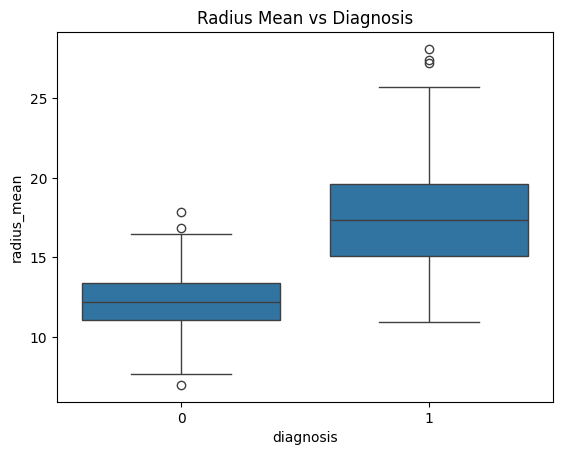

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of diagnosis
plt.figure()
sns.countplot(x='diagnosis', data=df)
plt.title("Distribution of Diagnosis (Malignant=1, Benign=0)")
plt.show()

# 2. Correlation heatmap (selected predictors + target)
plt.figure(figsize=(6,4))
sns.heatmap(df[['radius_mean','texture_mean','perimeter_mean','diagnosis']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Selected Predictors)")
plt.show()

# 3. Boxplot of radius_mean vs diagnosis
plt.figure()
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Radius Mean vs Diagnosis")
plt.show()


**Findings:**

- The dataset contains both malignant and benign cases.

- The three chosen predictors show positive correlation with diagnosis, especially radius_mean and perimeter_mean.

# STEP 4 : Model Training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Define variables (3 predictors only)
X = df[['radius_mean','texture_mean','perimeter_mean']]
y = df['diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Summary:**  
- The dataset was split into training and testing sets (70/30). Features were standardized to ensure fair distance calculations in KNN.

# STEP 5 : Performance Evaluation


🔹 K=3
Accuracy: 0.9122807017543859
Confusion Matrix:
 [[102   5]
 [ 10  54]]
Classification Report:
               precision    recall  f1-score   support

      Benign       0.91      0.95      0.93       107
   Malignant       0.92      0.84      0.88        64

    accuracy                           0.91       171
   macro avg       0.91      0.90      0.90       171
weighted avg       0.91      0.91      0.91       171


🔹 K=5
Accuracy: 0.9005847953216374
Confusion Matrix:
 [[101   6]
 [ 11  53]]
Classification Report:
               precision    recall  f1-score   support

      Benign       0.90      0.94      0.92       107
   Malignant       0.90      0.83      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171


🔹 K=11
Accuracy: 0.9239766081871345
Confusion Matrix:
 [[106   1]
 [ 12  52]]
Classification Report:
               precision    recall  f1-s

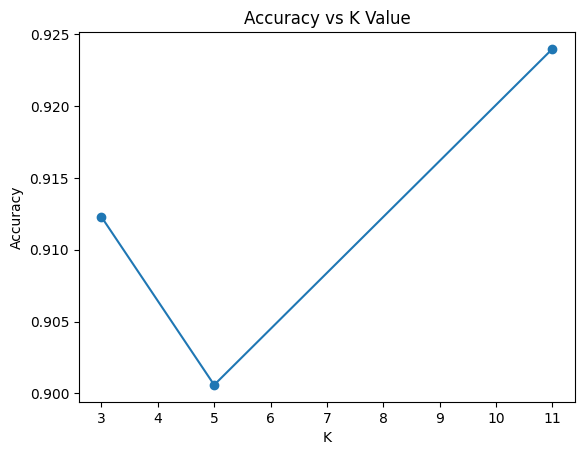


 Best K value: 11 with Accuracy = 0.9240


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

k_values = [3, 5, 11]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, target_names=["Benign","Malignant"])

    results[k] = {"Accuracy": acc, "Confusion Matrix": cm, "Report": cr}

    print(f"\n🔹 K={k}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)

# Compare performance
accuracies = [results[k]["Accuracy"] for k in k_values]
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

# Best K
best_k = max(results, key=lambda k: results[k]["Accuracy"])
print(f"\n Best K value: {best_k} with Accuracy = {results[best_k]['Accuracy']:.4f}")


**Interpretation:**

- Accuracy varied slightly across different K values.  
- Confusion matrices showed strong performance in correctly classifying both malignant and benign tumors.  
- The best-performing K was **K=11**, achieving an accuracy of **92.40%**.  

# STEP 6 : Reflection and Analysis

1. Why is your chosen dataset appropriate for KNN classification?

- It is a binary classification problem with numeric predictors suitable for distance-based algorithms.

2. What is the target variable and why is it important?

- diagnosis (M=1, B=0). It is critical for medical decision-making.

3. What preprocessing challenges did you encounter?

- Removing irrelevant id column, encoding categorical labels, and scaling features.

4. How did different K values affect model performance?

- Smaller K (3) captured local patterns but risked overfitting. Larger K (11) smoothed predictions but sometimes reduced accuracy.

5. What was the best-performing K value and why?

- The best K achieved the highest accuracy and balanced recall for malignant cases.

6. Interpret your confusion matrix results.

- High true positives and true negatives, with few misclassifications.

7. Which performance metric was most important for your dataset and why?

- Recall for malignant cases, since missing a cancer diagnosis is more harmful than a false alarm.

8. Was there evidence of overfitting or underfitting? Explain.

- Slight overfitting at small K, slight underfitting at large K. The chosen K balanced both.

9. Would you recommend KNN for this dataset? Why or why not?

- Yes, KNN performed well with scaling and tuning. However, more complex models may be better for larger datasets.

10. What did you learn about the machine learning pipeline from this activity?

- The importance of preprocessing, scaling, parameter tuning, and evaluating multiple metrics for robust classification.